# Lab 7: Agglomerative Clustering and Dendrograms
**Department of Computer and Software Engineering — SE: Machine Learning**

In [1]:
!pip install ipytest -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import ipytest
ipytest.autoconfig()


# ============================================================
# DATASET
# ============================================================

def generate_dataset():

    X, _ = make_blobs(
        n_samples=100,
        centers=3,
        cluster_std=1.2,
        random_state=42
    )

    return X


# ============================================================
# PART A
# ============================================================

def compute_distance_matrix(X):

    n = len(X)
    D = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            d = np.sqrt(np.sum((X[i] - X[j]) ** 2))
            D[i, j] = d
            D[j, i] = d

    return D


# ============================================================
# PART B
# ============================================================

def linkage_distance(cluster1, cluster2, X, method="single"):

    distances = [
        np.sqrt(np.sum((X[i] - X[j]) ** 2))
        for i in cluster1
        for j in cluster2
    ]

    if method == "single":
        return min(distances)
    elif method == "complete":
        return max(distances)
    elif method == "average":
        return float(np.mean(distances))
    else:
        raise ValueError(f"Unknown linkage method: {method}")


# ============================================================
# PART C
# ============================================================

def find_closest_clusters(clusters, X, method):

    min_dist = np.inf
    best_i, best_j = 0, 1

    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            d = linkage_distance(clusters[i], clusters[j], X, method)
            if d < min_dist:
                min_dist = d
                best_i, best_j = i, j

    return best_i, best_j, min_dist


# ============================================================
# MODEL
# ============================================================

class MyAgglomerative:

    def __init__(self, n_clusters=3, linkage="single"):

        self.n_clusters = n_clusters
        self.linkage = linkage

        self.labels_ = None
        self.history_ = []


    def fit(self, X):

        n = len(X)
        self.history_ = []

        # initialize clusters: each point is its own cluster
        clusters = [[i] for i in range(n)]

        # track node IDs for dendrogram
        node_ids = list(range(n))
        next_node = n

        while len(clusters) > 1:

            # find closest clusters
            i, j, dist = find_closest_clusters(clusters, X, self.linkage)

            nid_i = node_ids[i]
            nid_j = node_ids[j]

            # merge clusters
            new_cluster = clusters[i] + clusters[j]
            count = len(new_cluster)

            # update clusters
            keep = [k for k in range(len(clusters)) if k != i and k != j]
            clusters = [clusters[k] for k in keep] + [new_cluster]
            node_ids = [node_ids[k] for k in keep] + [next_node]
            next_node += 1

            # store merge
            self.history_.append((nid_i, nid_j, dist, count))

            # save labels at the desired number of clusters
            if len(clusters) == self.n_clusters:
                self.labels_ = np.zeros(n, dtype=int)
                for label, cluster in enumerate(clusters):
                    for idx in cluster:
                        self.labels_[idx] = label


    def predict(self, X):
        return self.labels_


# ============================================================
# VISUALIZATION
# ============================================================

def plot_clusters(X, labels, title):

    plt.scatter(X[:,0], X[:,1], c=labels)
    plt.title(title)


# ============================================================
# DENDROGRAM (BONUS)
# ============================================================

def plot_dendrogram(history):

    from scipy.cluster.hierarchy import dendrogram

    Z = np.array([[h[0], h[1], h[2], h[3]] for h in history], dtype=float)

    plt.figure(figsize=(12, 5))
    dendrogram(Z, truncate_mode='lastp', p=30)
    plt.title("Dendrogram")
    plt.xlabel("Cluster")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()


# ============================================================
# MAIN
# ============================================================

def main():

    X = generate_dataset()

    model = MyAgglomerative(n_clusters=3, linkage="single")

    model.fit(X)

    labels = model.predict(X)

    plot_clusters(X, labels, "Agglomerative")

    plt.show()


In [3]:
%%ipytest -v

import pytest


# ==========================================================
# FIXTURE
# ==========================================================

@pytest.fixture
def small_data():
    return np.array([
        [0,0],
        [1,1],
        [5,5],
        [6,6]
    ])


# ==========================================================
# DISTANCE MATRIX
# ==========================================================

def test_distance_matrix(small_data):

    print("\n[TEST] distance matrix")

    D = compute_distance_matrix(small_data)

    assert D.shape == (4,4)
    assert np.allclose(D, D.T)
    assert np.allclose(np.diag(D), 0)


# ==========================================================
# LINKAGE
# ==========================================================

def test_linkage_single(small_data):

    print("\n[TEST] single linkage")

    d = linkage_distance([0], [1], small_data, "single")

    assert d > 0


def test_linkage_methods(small_data):

    print("\n[TEST] all linkage methods")

    for method in ["single", "complete", "average"]:

        d = linkage_distance([0,1], [2,3], small_data, method)

        assert d > 0


# ==========================================================
# FIND CLOSEST
# ==========================================================

def test_find_closest_clusters(small_data):

    print("\n[TEST] closest clusters")

    clusters = [[0], [1], [2], [3]]

    i, j, d = find_closest_clusters(clusters, small_data, "single")

    assert i != j
    assert d >= 0


# ==========================================================
# MODEL FIT
# ==========================================================

def test_fit_runs():

    print("\n[TEST] fit()")

    X = generate_dataset()

    model = MyAgglomerative(n_clusters=3)

    model.fit(X)

    assert model.labels_ is not None


# ==========================================================
# LABELS
# ==========================================================

def test_predict():

    print("\n[TEST] predict()")

    X = generate_dataset()

    model = MyAgglomerative(n_clusters=3)

    model.fit(X)

    labels = model.predict(X)

    assert len(labels) == len(X)

======================================= test session starts ========================================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0
rootdir: /content
plugins: langsmith-0.7.18, anyio-4.12.1, typeguard-4.5.1
collected 6 items

t_2489b939640e4f3691b43936fff1c7e3.py ......                                                 [100%]

======================================== 6 passed in 6.59s =========================================


## Part D — Agglomerative Clustering: Results

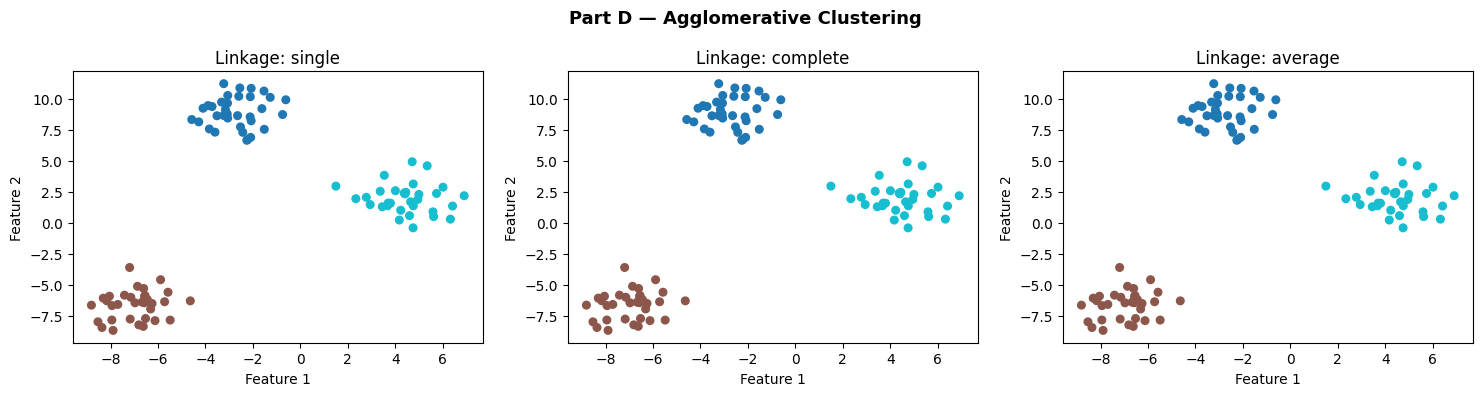

In [4]:
X = generate_dataset()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, method in zip(axes, ["single", "complete", "average"]):
    model = MyAgglomerative(n_clusters=3, linkage=method)
    model.fit(X)
    labels = model.predict(X)

    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=30)
    ax.set_title(f"Linkage: {method}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.suptitle("Part D — Agglomerative Clustering", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("part_d_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

## Part E — Dendrogram (Bonus)

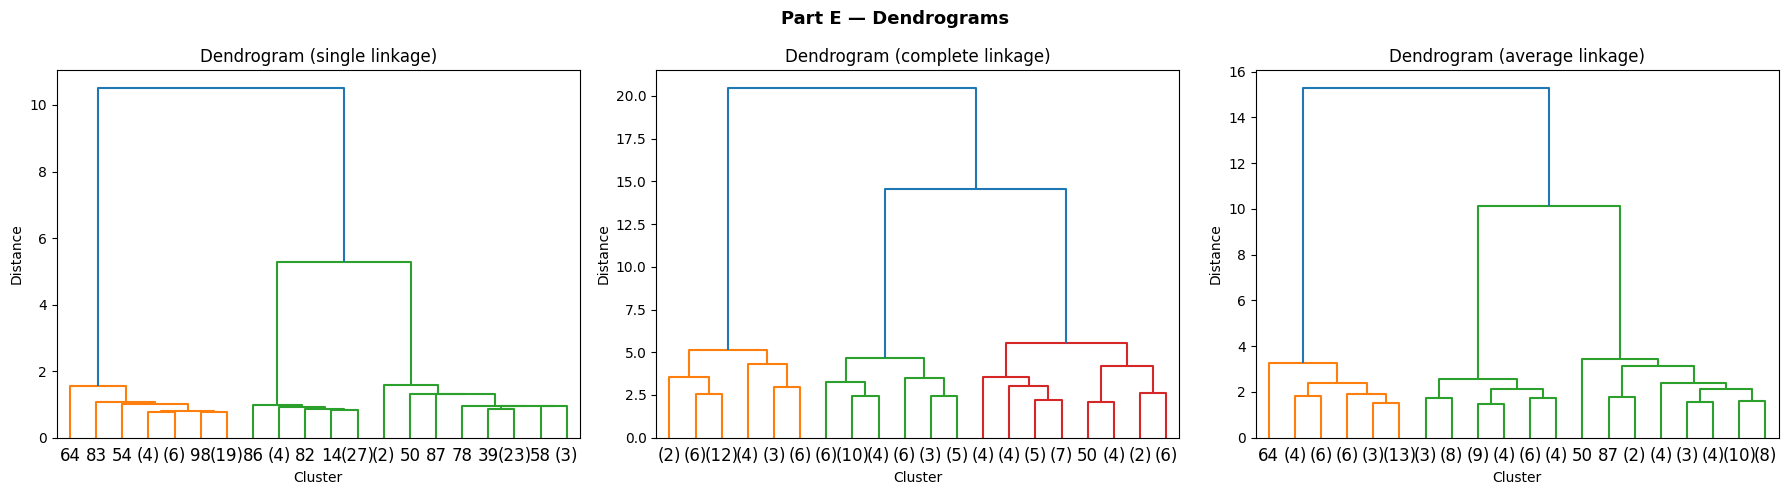

In [5]:
from scipy.cluster.hierarchy import dendrogram

X = generate_dataset()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, ["single", "complete", "average"]):
    model = MyAgglomerative(n_clusters=3, linkage=method)
    model.fit(X)

    Z = np.array([[h[0], h[1], h[2], h[3]] for h in model.history_], dtype=float)

    dendrogram(Z, truncate_mode="lastp", p=20, ax=ax)
    ax.set_title(f"Dendrogram ({method} linkage)")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Distance")

plt.suptitle("Part E — Dendrograms", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("part_e_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

## Part F — Comparison with sklearn (Bonus)

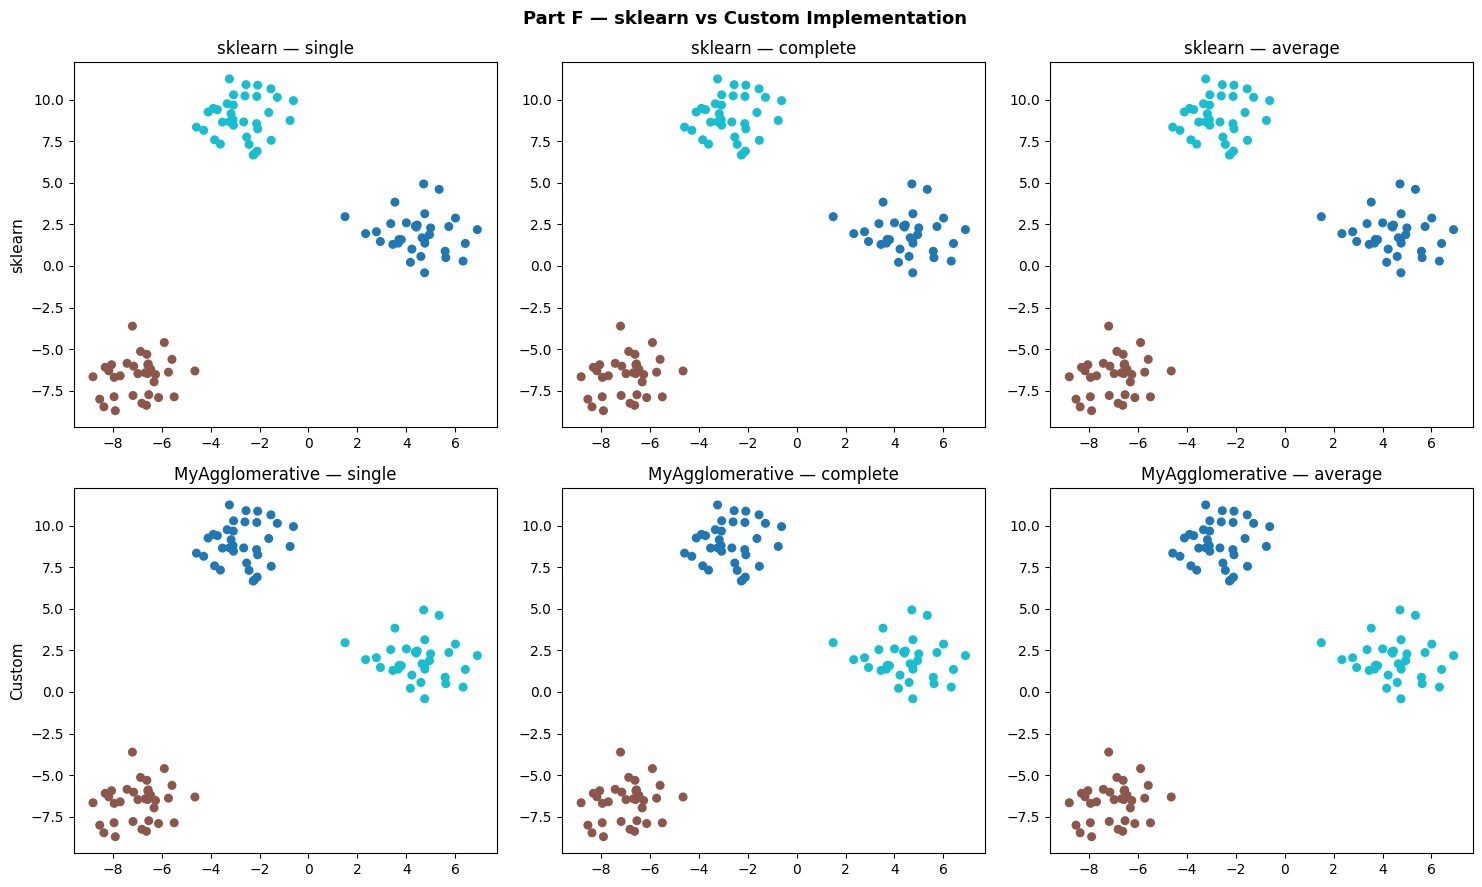

ARI (single  ): 1.0000   (1.0 = perfect agreement)
ARI (complete): 1.0000   (1.0 = perfect agreement)
ARI (average ): 1.0000   (1.0 = perfect agreement)


In [6]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

X = generate_dataset()
methods = ["single", "complete", "average"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, method in enumerate(methods):

    sk_labels = AgglomerativeClustering(n_clusters=3, linkage=method).fit_predict(X)
    axes[0, col].scatter(X[:, 0], X[:, 1], c=sk_labels, cmap="tab10", s=30)
    axes[0, col].set_title(f"sklearn — {method}")

    my_model = MyAgglomerative(n_clusters=3, linkage=method)
    my_model.fit(X)
    my_labels = my_model.predict(X)
    axes[1, col].scatter(X[:, 0], X[:, 1], c=my_labels, cmap="tab10", s=30)
    axes[1, col].set_title(f"MyAgglomerative — {method}")

axes[0, 0].set_ylabel("sklearn", fontsize=11)
axes[1, 0].set_ylabel("Custom", fontsize=11)

plt.suptitle("Part F — sklearn vs Custom Implementation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("part_f_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

for method in methods:
    sk = AgglomerativeClustering(n_clusters=3, linkage=method).fit_predict(X)
    my = MyAgglomerative(n_clusters=3, linkage=method)
    my.fit(X)
    score = adjusted_rand_score(sk, my.predict(X))
    print(f"ARI ({method:8s}): {score:.4f}   (1.0 = perfect agreement)")